# Assignment 03 — Networks

## Euclidean vs network distance in my affective Milan

This notebook follows the course tutorial [`04_networks.ipynb`](../../Tutorials/04_networks.ipynb) (`osmnx`, `networkx`) and applies it to the personal Milan geography from Assignment 02.

### Research statement

I move through Milan mainly by bicycle. The places that matter to me — home, friends' homes, parks, bars, study and work sites — form a personal geography of the city. Official maps and straight-line (Euclidean) distance suggest that some destinations are "close." Everyday cycling, however, follows the street network: one-way systems, bridges, parks that block through-routes, and missing cycle links stretch or shorten lived distance.

**Research question:** for the places that make up my affective Milan, how does *network* (bicycle) distance from home differ from *Euclidean* distance, and what does that gap say about the experiential geography of moving by bike?

### What this notebook does

1. Rebuilds the tutorial's **abstract network** (k-nearest neighbors) to fix concepts of nodes and edges.
2. Loads my **personal places** GeoJSON.
3. Downloads a **bicycle street network** from OpenStreetMap with OSMnx.
4. Measures **Euclidean** and **network** distance from home to every destination.
5. Produces **maps and charts**, then a short **reflection**.


## 0. Import libraries

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString
import pandas as pd
import networkx as nx
import osmnx as ox
from pathlib import Path

from cdptools import utils

utils.set_axis_off()
ox.settings.use_cache = True
ox.settings.log_console = False

DATA_DIR = Path(".").resolve()
PLACES_PATH = DATA_DIR / "02-Psychogeograpy-MyMilan.geojson"

## 1. Abstract network (tutorial warm-up)

As in the tutorial, we start with a toy graph: random points connected to their *k* nearest neighbors by Euclidean distance. This makes the vocabulary of **nodes** and **edges** concrete before we move to a real street network.


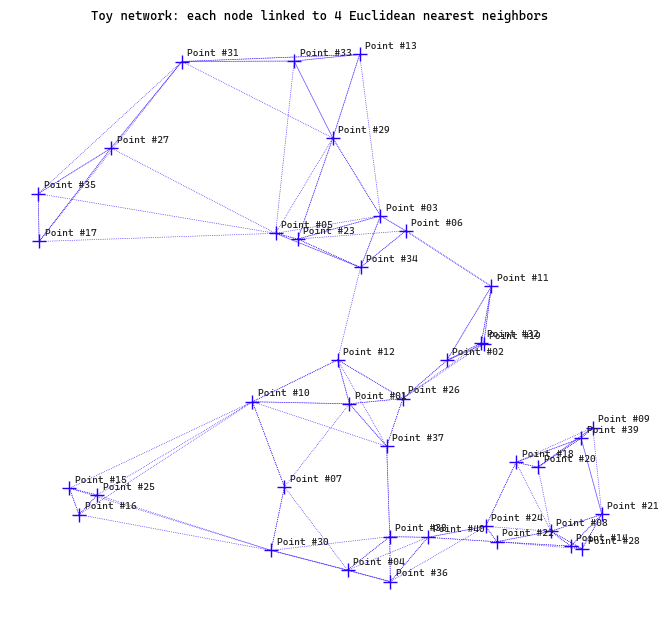

In [3]:
from matplotlib import font_manager

# Cascadia Code font (course assets)
FONT_PATH = (
    Path("..") / "assets" / "fonts" / "CascadiaCode" / "CascadiaCode.ttf"
).resolve()
font_manager.fontManager.addfont(str(FONT_PATH))
cascadia = font_manager.FontProperties(fname=str(FONT_PATH))
plt.rcParams["font.family"] = cascadia.get_name()

ELECTRIC_BLUE = "#2600FF"

# Bounding box roughly covering my personal places in Milan
bbox_milan = (9.17, 45.44, 9.29, 45.52)  # west, south, east, north

np.random.seed(0)
n = 40
toy = gpd.GeoDataFrame(
    {
        "geometry": gpd.points_from_xy(
            np.random.uniform(bbox_milan[0], bbox_milan[2], n),
            np.random.uniform(bbox_milan[1], bbox_milan[3], n),
        )
    },
    crs="EPSG:4326",
)
toy["label"] = [f"Point #{i:02d}" for i in range(1, len(toy) + 1)]

# Project to meters for meaningful neighbor distances
toy_m = toy.to_crs(32632)
toy_m["label"] = toy["label"].values

k = 4
neighbors = toy_m.geometry.apply(lambda x: toy_m.geometry.distance(x)).values.argsort(
    axis=1
)[:, 1 : k + 1]
toy_m["neighbors"] = neighbors.tolist()


def create_lines(row, nodes):
    lines = [LineString([row.geometry, nodes.loc[j].geometry]) for j in row.neighbors]
    return MultiLineString(lines)


toy_m["line_geometry"] = toy_m.apply(create_lines, nodes=toy_m, axis=1)
toy_edges = gpd.GeoDataFrame(
    toy_m[["line_geometry"]], geometry="line_geometry", crs=toy_m.crs
)

fig, ax = plt.subplots(figsize=(8, 8))

# Dotted electric-blue edges (draw explicitly so linestyle is respected)
for geom in toy_edges.geometry:
    lines = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
    for line in lines:
        xs, ys = line.xy
        ax.plot(
            xs,
            ys,
            color=ELECTRIC_BLUE,
            linestyle=":",
            linewidth=0.5,
            solid_capstyle="round",
            zorder=1,
        )

toy_m.plot(
    ax=ax,
    color=ELECTRIC_BLUE,
    markersize=90,
    marker="+",
    linewidth=1,
    zorder=3,
)

# Point labels next to each node
for _idx, row in toy_m.iterrows():
    ax.annotate(
        row["label"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        fontproperties=cascadia,
        color="#222222",
    )

ax.set_title(
    "Toy network: each node linked to 4 Euclidean nearest neighbors",
    fontproperties=cascadia,
    fontsize=9,
)
plt.show()

## 2. Load personal places (nodes of interest)

These are the **nodes for which we measure distance**: home as origin; friends' homes and favorite places as destinations.


In [4]:
places = gpd.read_file(PLACES_PATH)
assert places.crs.to_epsg() == 4326

home = places[places["category"] == "home_origin"].copy()
destinations = places[places["category"] != "home_origin"].copy()

print(places["category"].value_counts())
places.head()

category
favorite_place    27
friends_home       5
home_origin        1
Name: count, dtype: int64


,name,category,privacy,precision,subcategory,verification,geometry
0,Home — relational origin,home_origin,approximate_location,neighborhood,NaN,NaN,POINT (9.2362 45.4792)
1,Friend's home 1,friends_home,approximate_location,neighborhood,NaN,NaN,POINT (9.2322 45.4689)
2,Friend's home 2,friends_home,approximate_location,neighborhood,NaN,NaN,POINT (9.2251 45.4652)
3,Friend's home 3,friends_home,approximate_location,neighborhood,NaN,NaN,POINT (9.2167 45.484)
4,Friend's home 4,friends_home,approximate_location,neighborhood,NaN,NaN,POINT (9.2232 45.4704)


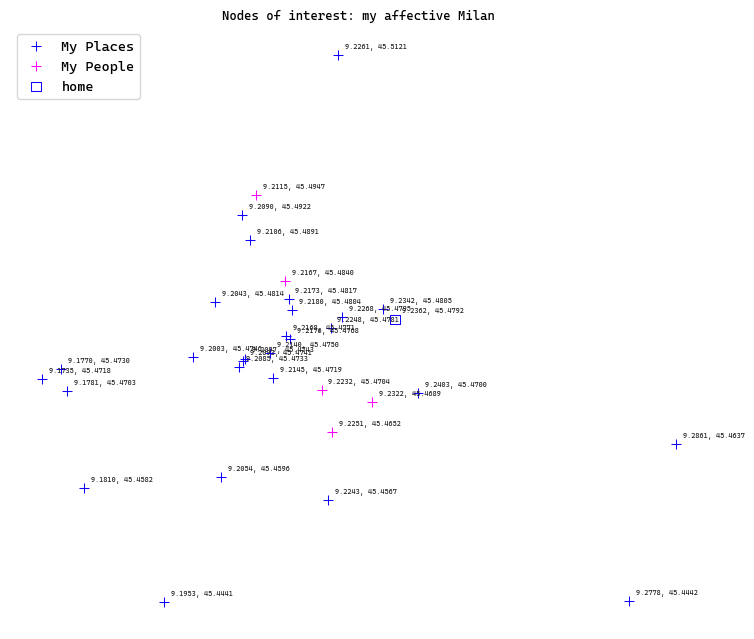

In [10]:
from matplotlib import font_manager

FONT_PATH = (
    Path("..") / "assets" / "fonts" / "CascadiaCode" / "CascadiaCode.ttf"
).resolve()
font_manager.fontManager.addfont(str(FONT_PATH))
cascadia = font_manager.FontProperties(fname=str(FONT_PATH))
plt.rcParams["font.family"] = cascadia.get_name()

ELECTRIC_BLUE = "#1100FF"
FUCHSIA = "#FF00FF"

favorites = places[places["category"] == "favorite_place"]
friends = places[places["category"] == "friends_home"]

fig, ax = plt.subplots(figsize=(9, 9))

favorites.plot(
    ax=ax,
    color=ELECTRIC_BLUE,
    markersize=50,
    marker="+",
    linewidth=0.75,
    label="My Places",
    zorder=3,
)
friends.plot(
    ax=ax,
    color=FUCHSIA,
    markersize=50,
    marker="+",
    linewidth=0.75,
    label="My People",
    zorder=4,
)
# Home: hollow square with electric-blue border only
ax.scatter(
    home.geometry.x,
    home.geometry.y,
    s=50,
    marker="s",
    facecolors="none",
    edgecolors=ELECTRIC_BLUE,
    linewidths=0.75,
    label="home",
    zorder=5,
)

# Geographic coordinates next to every point
for _idx, row in places.iterrows():
    ax.annotate(
        f"{row.geometry.x:.4f}, {row.geometry.y:.4f}",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=5,
        fontproperties=cascadia,
        color="#222222",
    )

legend = ax.legend(loc="upper left", frameon=True, prop=cascadia)
ax.set_title(
    "Nodes of interest: my affective Milan", fontproperties=cascadia, fontsize=9
)
plt.show()

## 3. Build the bicycle street network (OSMnx)

Following the tutorial's street-graph pattern, we download the **bike** network for a bounding box that covers all personal places (with a small buffer). Edges become traversable street segments; graph nodes are intersections.

> First run needs internet access and may take a minute; OSMnx caches the download for later runs.


In [11]:
# Buffer the places bbox slightly so routes near the edge stay connected
minx, miny, maxx, maxy = places.total_bounds
pad = 0.012  # ~1 km in lon/lat at Milan latitude
bbox = (minx - pad, miny - pad, maxx + pad, maxy + pad)  # west, south, east, north

print("Downloading bicycle network for bbox:", bbox)
bike_network = ox.graph_from_bbox(bbox=bbox, network_type="bike")
bike_network = ox.add_edge_speeds(bike_network)
bike_network = ox.add_edge_travel_times(bike_network)

net_nodes, net_edges = ox.graph_to_gdfs(bike_network)
print(f"Nodes: {len(net_nodes):,} | Edges: {len(net_edges):,}")

Nodes: 19,341 | Edges: 40,693


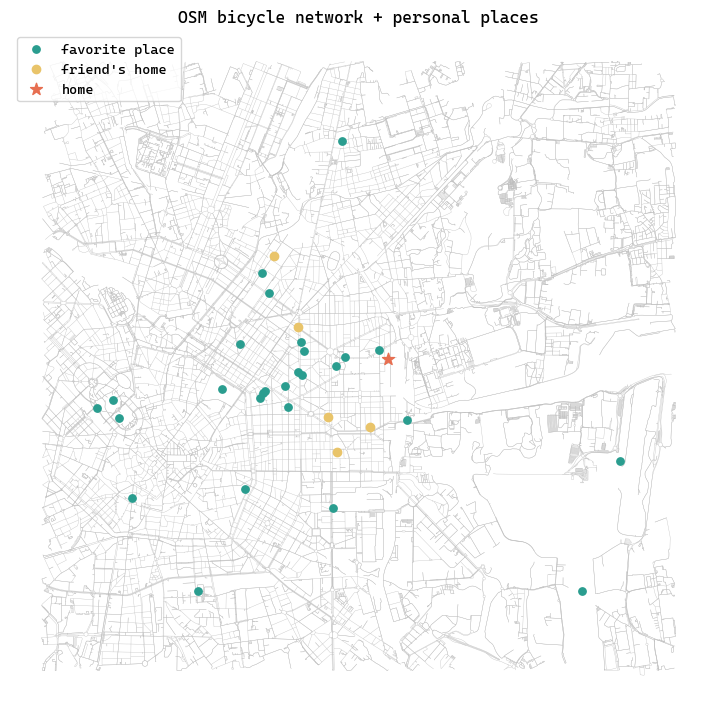

In [35]:
fig, ax = plt.subplots(figsize=(9, 9))
net_edges.plot(ax=ax, color="0.75", linewidth=0.25, zorder=1)
places[places["category"] == "favorite_place"].plot(
    ax=ax, color="#2a9d8f", markersize=28, zorder=3, label="favorite place"
)
places[places["category"] == "friends_home"].plot(
    ax=ax, color="#e9c46a", markersize=36, zorder=4, label="friend's home"
)
home.plot(ax=ax, color="#e76f51", markersize=80, marker="*", zorder=5, label="home")
ax.legend(loc="upper left")
ax.set_title("OSM bicycle network + personal places")
plt.show()

## 4. Snap places to the network

As in the tutorial: associate each geographic point with the **nearest graph node** before computing shortest paths.


In [36]:
home_node = ox.distance.nearest_nodes(
    bike_network, home.geometry.x.iloc[0], home.geometry.y.iloc[0]
)

destinations = destinations.copy()
destinations["net_node"] = ox.distance.nearest_nodes(
    bike_network, destinations.geometry.x, destinations.geometry.y
)

print("Home network node:", home_node)
destinations[["name", "category", "net_node"]].head()

Home network node: 6919857056


,name,category,net_node
1,Friend's home 1,friends_home,3696911821
2,Friend's home 2,friends_home,29765455
3,Friend's home 3,friends_home,306377053
4,Friend's home 4,friends_home,442095658
5,Friend's home 5,friends_home,250154658


## 5. Euclidean vs network distance

For each destination we compute:

- **Euclidean distance** — straight-line distance in meters (`EPSG:32632`).
- **Network distance** — shortest path along the bike graph, weighted by edge `length` (tutorial method: `ox.shortest_path` + `ox.routing.route_to_gdf`).
- **Detour ratio** — network / Euclidean (values > 1 mean the street network forces a longer trip than "as the crow flies").


In [37]:
places_m = places.to_crs(32632)
home_m = places_m[places_m["category"] == "home_origin"].geometry.iloc[0]


def network_route_from_home(row, graph, origin_node):
    dest_node = int(row["net_node"])
    route = ox.shortest_path(graph, origin_node, dest_node, weight="length")
    if route is None or len(route) < 2:
        return {
            "network_m": np.nan,
            "route_geom": None,
            "n_edges": 0,
        }
    route_gdf = ox.routing.route_to_gdf(graph, route)
    return {
        "network_m": float(route_gdf["length"].sum()),
        "route_geom": route_gdf.geometry.union_all(),
        "n_edges": len(route_gdf),
    }


# Euclidean distance in projected meters
dest_m = destinations.to_crs(32632)
destinations["euclidean_m"] = dest_m.geometry.distance(home_m)

# Network distance + route geometry
route_info = destinations.apply(
    network_route_from_home, graph=bike_network, origin_node=home_node, axis=1
)
destinations = pd.concat([destinations, route_info.apply(pd.Series)], axis=1)

destinations["detour_ratio"] = destinations["network_m"] / destinations["euclidean_m"]
destinations["euclidean_km"] = destinations["euclidean_m"] / 1000
destinations["network_km"] = destinations["network_m"] / 1000

results = destinations[
    [
        "name",
        "category",
        "subcategory",
        "euclidean_km",
        "network_km",
        "detour_ratio",
        "n_edges",
        "geometry",
        "route_geom",
    ]
].sort_values("network_km")

results.head(10)

,name,category,subcategory,euclidean_km,network_km,detour_ratio,n_edges,geometry,route_geom
19,Il Bancale,favorite_place,bar,0.215386,0.429129,1.992375,6,POINT (9.23417 45.48051),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
13,Politecnico — Patio,favorite_place,university,0.734798,1.062391,1.445827,12,POINT (9.22681 45.47953),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
20,Piazza Leonardo da Vinci,favorite_place,public_space,0.898339,1.436111,1.598628,22,POINT (9.2248 45.47814),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
1,Friend's home 1,friends_home,NaN,1.186243,1.646573,1.388057,20,POINT (9.2322 45.4689),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
24,Bar Basso,favorite_place,bar,1.480090,1.878104,1.268912,32,POINT (9.21758 45.47677),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
7,Caffè degli Artisti,favorite_place,bar,1.531626,1.933191,1.262182,35,POINT (9.21682 45.47715),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
10,La Balera dell'Ortica,favorite_place,music_and_social_life,1.066787,1.963898,1.840947,27,POINT (9.2403 45.47004),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
4,Friend's home 4,friends_home,NaN,1.410063,2.019080,1.431907,26,POINT (9.2232 45.4704),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
3,Friend's home 3,friends_home,NaN,1.614581,2.030469,1.257583,31,POINT (9.2167 45.484),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."
8,La Belle Aurore,favorite_place,bar,1.877879,2.225011,1.184854,36,POINT (9.21451 45.47193),"MULTILINESTRING ((9.2366095 45.4793854, 9.2366..."


### Summary table

In [38]:
summary = results[
    ["name", "category", "euclidean_km", "network_km", "detour_ratio"]
].copy()
summary["euclidean_km"] = summary["euclidean_km"].round(2)
summary["network_km"] = summary["network_km"].round(2)
summary["detour_ratio"] = summary["detour_ratio"].round(2)
summary

,name,category,euclidean_km,network_km,detour_ratio
19,Il Bancale,favorite_place,0.22,0.43,1.99
13,Politecnico — Patio,favorite_place,0.73,1.06,1.45
20,Piazza Leonardo da Vinci,favorite_place,0.90,1.44,1.60
1,Friend's home 1,friends_home,1.19,1.65,1.39
24,Bar Basso,favorite_place,1.48,1.88,1.27
7,Caffè degli Artisti,favorite_place,1.53,1.93,1.26
10,La Balera dell'Ortica,favorite_place,1.07,1.96,1.84
4,Friend's home 4,friends_home,1.41,2.02,1.43
3,Friend's home 3,friends_home,1.61,2.03,1.26
8,La Belle Aurore,favorite_place,1.88,2.23,1.18


## 6. Maps

### 6.1 Shortest bicycle routes from home


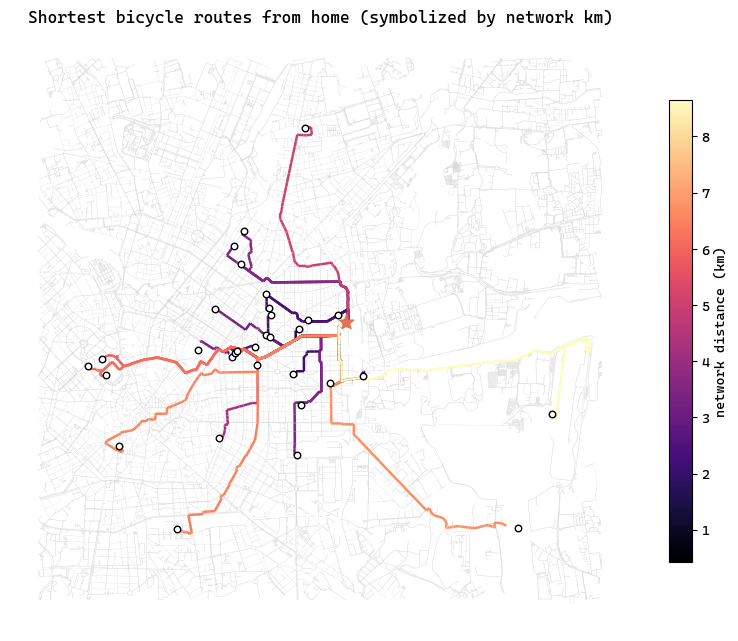

In [39]:
routes_gdf = gpd.GeoDataFrame(
    results.dropna(subset=["route_geom"]).copy(),
    geometry="route_geom",
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(10, 10))
net_edges.plot(ax=ax, color="0.85", linewidth=0.2, zorder=1)
routes_gdf.plot(
    ax=ax,
    column="network_km",
    cmap="magma",
    linewidth=1.8,
    legend=True,
    legend_kwds={"label": "network distance (km)", "shrink": 0.6},
    zorder=2,
)
places.plot(ax=ax, color="white", edgecolor="black", markersize=22, zorder=3)
home.plot(ax=ax, color="#e76f51", markersize=120, marker="*", zorder=4)
ax.set_title("Shortest bicycle routes from home (symbolized by network km)")
plt.show()

### 6.2 One destination: Euclidean line vs network path

Pick the destination with the highest detour ratio to make the experiential gap visible.


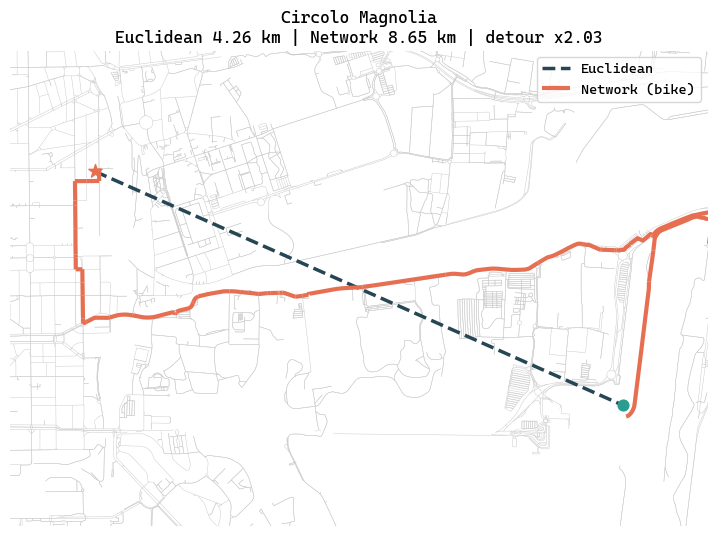

In [40]:
# Highest detour among reachable destinations
focus = (
    results.dropna(subset=["route_geom"])
    .sort_values("detour_ratio", ascending=False)
    .iloc[0]
)
home_pt = home.geometry.iloc[0]
dest_pt = focus.geometry
eucl_line = gpd.GeoDataFrame(geometry=[LineString([home_pt, dest_pt])], crs="EPSG:4326")
route_line = gpd.GeoDataFrame(geometry=[focus.route_geom], crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(9, 9))
pad_m = 0.008
xs = [home_pt.x, dest_pt.x]
ys = [home_pt.y, dest_pt.y]
ax.set_xlim(min(xs) - pad_m, max(xs) + pad_m)
ax.set_ylim(min(ys) - pad_m, max(ys) + pad_m)

net_edges.plot(ax=ax, color="0.8", linewidth=0.35, zorder=1)
eucl_line.plot(
    ax=ax, color="#264653", linewidth=2.5, linestyle="--", label="Euclidean", zorder=3
)
route_line.plot(ax=ax, color="#e76f51", linewidth=3, label="Network (bike)", zorder=4)
gpd.GeoSeries([home_pt], crs=4326).plot(
    ax=ax, color="#e76f51", markersize=100, marker="*", zorder=5
)
gpd.GeoSeries([dest_pt], crs=4326).plot(ax=ax, color="#2a9d8f", markersize=60, zorder=5)
ax.legend(loc="best")
ax.set_title(
    f"{focus['name']}\n"
    f"Euclidean {focus['euclidean_km']:.2f} km | "
    f"Network {focus['network_km']:.2f} km | "
    f"detour x{focus['detour_ratio']:.2f}"
)
plt.show()

## 7. Charts

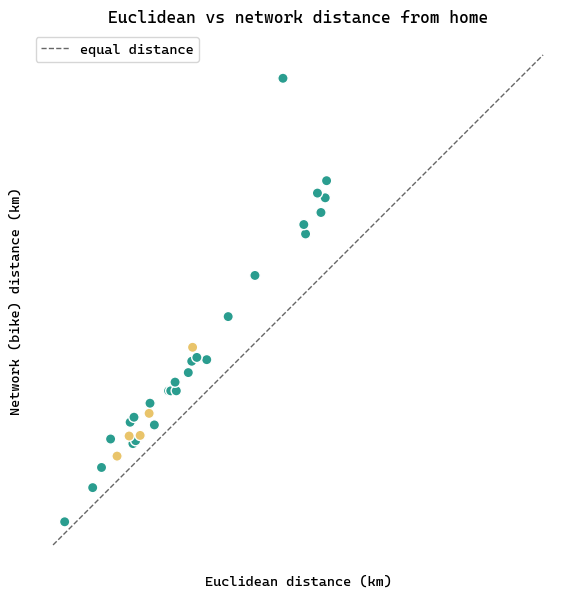

In [41]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = results["category"].map(
    {"friends_home": "#e9c46a", "favorite_place": "#2a9d8f"}
)
ax.scatter(
    results["euclidean_km"],
    results["network_km"],
    c=colors,
    s=55,
    edgecolor="white",
)
lim = max(results["euclidean_km"].max(), results["network_km"].max()) * 1.05
ax.plot(
    [0, lim],
    [0, lim],
    color="0.4",
    linestyle="--",
    linewidth=1,
    label="equal distance",
)
ax.set_xlabel("Euclidean distance (km)")
ax.set_ylabel("Network (bike) distance (km)")
ax.set_title("Euclidean vs network distance from home")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
plt.show()

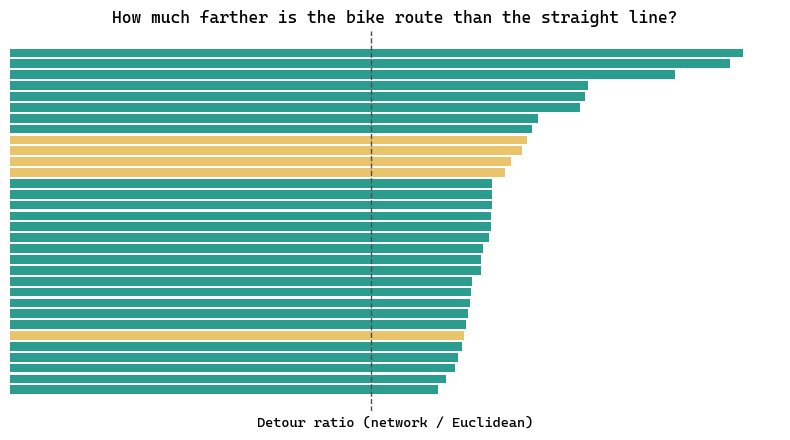

In [42]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = results.sort_values("detour_ratio")
ax.barh(
    plot_df["name"],
    plot_df["detour_ratio"],
    color=plot_df["category"].map(
        {"friends_home": "#e9c46a", "favorite_place": "#2a9d8f"}
    ),
)
ax.axvline(1.0, color="0.3", linestyle="--", linewidth=1)
ax.set_xlabel("Detour ratio (network / Euclidean)")
ax.set_title("How much farther is the bike route than the straight line?")
plt.tight_layout()
plt.show()

In [43]:
print("Mean detour ratio:", round(results["detour_ratio"].mean(), 2))
print("Median detour ratio:", round(results["detour_ratio"].median(), 2))
print(
    "Max detour:",
    results.loc[results["detour_ratio"].idxmax(), "name"],
    round(results["detour_ratio"].max(), 2),
)
print(
    "Min detour:",
    results.loc[results["detour_ratio"].idxmin(), "name"],
    round(results["detour_ratio"].min(), 2),
)

Mean detour ratio: 1.4
Median detour ratio: 1.33
Max detour: Circolo Magnolia 2.03
Min detour: La Belle Aurore 1.18


## 8. Optional: bike reach from home (tutorial isochrone pattern)

The tutorial builds walking isochrones with `nx.ego_graph` and travel time. Below we sketch approximate **5 / 10 / 15 minute** bicycle reach from home.


In [44]:
trip_minutes = [5, 10, 15]
for _u, _v, _k, data in bike_network.edges(keys=True, data=True):
    # travel_time from OSMnx is in seconds; fallback ~15 km/h if missing
    data["time_min"] = data.get("travel_time", data["length"] / 4.1667) / 60

iso_colors = ox.plot.get_colors(n=len(trip_minutes), cmap="plasma", start=0)
node_colors = {}
for trip_time, color in zip(sorted(trip_minutes, reverse=True), iso_colors):
    subgraph = nx.ego_graph(
        bike_network, home_node, radius=trip_time, distance="time_min"
    )
    for node in subgraph.nodes():
        node_colors[node] = color

nc = [node_colors.get(n, "none") for n in bike_network.nodes()]
ns = [12 if n in node_colors else 0 for n in bike_network.nodes()]

fig, ax = ox.plot_graph(
    bike_network,
    node_color=nc,
    node_size=ns,
    node_alpha=0.85,
    edge_linewidth=0.2,
    edge_color="#bbbbbb",
    bgcolor="white",
    show=False,
    close=False,
)
home.plot(ax=ax, color="#e76f51", markersize=80, marker="*", zorder=5)
ax.set_title("Bike reach from home (approx. 5 / 10 / 15 minutes)")
plt.show()

KeyboardInterrupt: 

## 9. Reflection

*(Edit this cell after you run the notebook and inspect the maps/charts.)*

### What the network shows

- Euclidean distance answers: *how far is this place if I could cut through buildings and rivers?*
- Network distance answers: *how far is this place if I actually cycle on streets that exist?*

Where the **detour ratio** is high, the city fabric forces me to travel farther than the map's straight line suggests — canals, rail corridors, one-way patterns, or sparse cycle links. Where it is close to 1, the street grid aligns well with my desire line from home.

### Experiential difference

On a bike, "closeness" is not only meters: it is also continuity of cycling infrastructure, sense of safety, and whether a route feels like a shortcut through a familiar neighborhood. Two destinations with similar Euclidean distance can feel very different if one sits on a direct cycle route and the other requires a long diversion.

### Next steps (optional)

- Intersect routes with the Comune di Milano *Itinerari ciclabili* layer (Assignment 02) to measure % of each trip on official cycling infrastructure.
- Compare `network_type="bike"` vs `"walk"` or `"drive"` for the same origin–destination pairs.
- Add travel-time weights that reflect perceived effort (hills, traffic) rather than length alone.


## Done

Deliverable checklist for Assignment 03:

- [x] Research statement stated
- [x] Network created (toy + OSM bike graph)
- [x] Nodes measured (home → friends / favorite places)
- [x] Euclidean vs network distance compared
- [x] Maps and charts produced
- [ ] Reflection finalized after interpreting *your* run outputs
